### Stochastic GD

In [1]:
from util import *
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso

**Data**

In [2]:
np.random.seed(2025)
n_points = 500
learning_rate = 0.05

l = 1e-4

epochs = 50
minibatch = 5

noise = 0.01 * np.random.randn(n_points,1)
x = np.linspace(-1, 1, n_points).reshape(-1,1)
y = Runge(x) + noise

maxdegree = 15

degrees = np.arange(1,maxdegree + 1)

**Recreating the plots from C,D,E with stochastic GD**

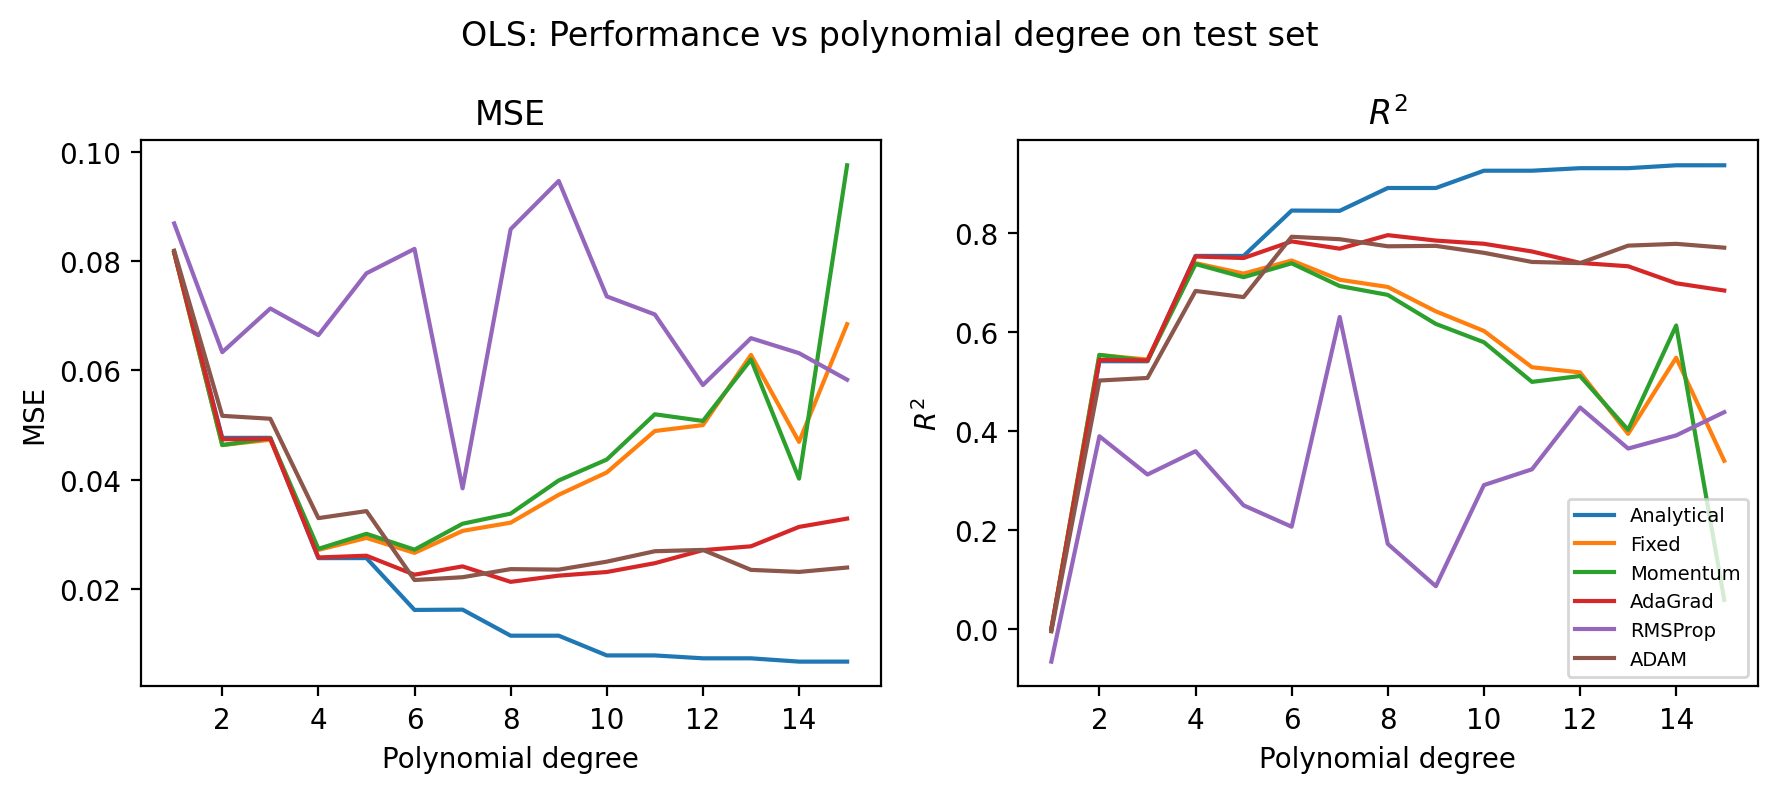

In [3]:
# Analytical, Fixed, Momentum, AdaGrad, RMSProp, ADAM
ols_mses = []
ols_r2s = []

for degree in degrees:
    X = PolynomialFeatures(degree = degree).fit_transform(x)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

    # Scaling
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)
    y_offset = np.mean(y_test)

    ols_mses_degree = []
    ols_r2s_degree = []

    # Plain OLS
    theta_OLS = OLS(X_train_s, y_train)
    OLS_predictions = X_test_s @ theta_OLS + y_offset
    ols_r2s_degree.append(r2_score(y_test, OLS_predictions))
    ols_mses_degree.append(mean_squared_error(y_test, OLS_predictions))

    # Gradient descent solver
    OLS_grad_descent_solver = gradient_descent(X_train_s, y_train, OLS_Gradient, learning_rate)
    theta_grad_descent = OLS_grad_descent_solver.gradient_descent_stochastic(epochs = epochs, minibatch_size = minibatch)
    grad_descent_predictions = X_test_s @ theta_grad_descent + y_offset
    ols_r2s_degree.append(r2_score(y_test, grad_descent_predictions))
    ols_mses_degree.append(mean_squared_error(y_test,   grad_descent_predictions))

    # Grad descent + momentum
    theta_momentum = OLS_grad_descent_solver.momentum_stochastic(alpha = 0.060, epochs=epochs, minibatch_size=minibatch)
    momentum_predictions = X_test_s @ theta_momentum + y_offset
    ols_r2s_degree.append(r2_score(y_test, momentum_predictions))
    ols_mses_degree.append(mean_squared_error(y_test, momentum_predictions))

    # Grad descent + AdaGrad
    theta_adagrad = OLS_grad_descent_solver.AdaGrad_stochastic(epochs=epochs, minibatch_size=minibatch)
    adagrad_predictions = X_test_s @ theta_adagrad + y_offset
    ols_r2s_degree.append(r2_score(y_test, adagrad_predictions))
    ols_mses_degree.append(mean_squared_error(y_test, adagrad_predictions))

    # Grad descent + RMSProp
    theta_rmsprop = OLS_grad_descent_solver.RMSProp_stochastic(rho = 0.99, epochs=epochs, minibatch_size=minibatch)
    rmsprop_predictions = X_test_s @ theta_rmsprop + y_offset
    ols_r2s_degree.append(r2_score(y_test,rmsprop_predictions))
    ols_mses_degree.append(mean_squared_error(y_test, rmsprop_predictions))

    # Grad descent + ADAM
    theta_adam = OLS_grad_descent_solver.ADAM_stochastic(rho1 = 0.9, rho2 = 0.999, epochs=epochs, minibatch_size=minibatch)
    adam_predictions = X_test_s @ theta_adam + y_offset
    ols_r2s_degree.append(r2_score(y_test, adam_predictions))   
    ols_mses_degree.append(mean_squared_error(y_test, adam_predictions))

    ols_mses.append(ols_mses_degree)
    ols_r2s.append(ols_r2s_degree)

ols_mses = np.array(ols_mses)
ols_r2s = np.array(ols_r2s)

methods = ["Analytical", "Fixed", "Momentum", "AdaGrad", "RMSProp", "ADAM"]

fig, ax = plt.subplots(1,2, figsize = (9,4), dpi = 200)
fig.suptitle("OLS: Performance vs polynomial degree on test set")

ax[0].set_title("MSE")
ax[1].set_title(r"$R^2$")
ax[0].set_xlabel("Polynomial degree")
ax[1].set_xlabel("Polynomial degree")
ax[0].set_ylabel("MSE")
ax[1].set_ylabel(r"$R^2$")

for i, method in enumerate(methods):
    ax[0].plot(degrees, ols_mses[:,i], label = method)
    ax[1].plot(degrees, ols_r2s[:,i], label = method)

ax[1].legend(prop = {'size': 7})
fig.tight_layout()

<Figure size 640x480 with 0 Axes>

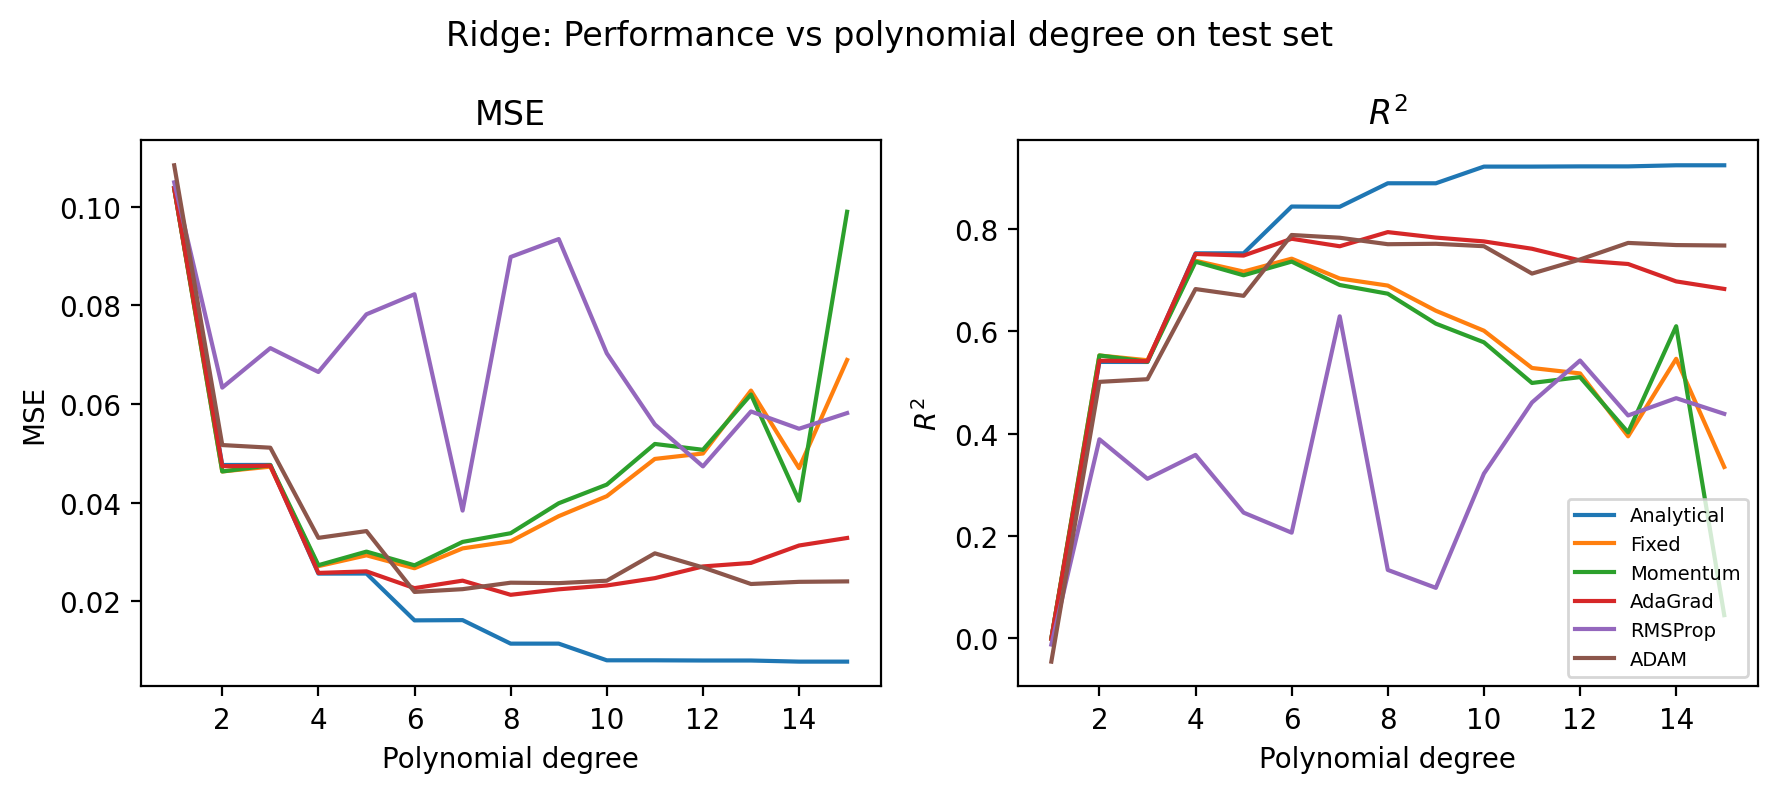

In [4]:
# Analytical, Fixed, Momentum, AdaGrad, RMSProp, ADAM
ridge_mses = []
ridge_r2s = []

for degree in degrees:
    X = PolynomialFeatures(degree = degree).fit_transform(x)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

    # Scaling
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)
    y_offset = np.mean(y_test)

    ridge_mses_degree = []
    ridge_r2s_degree = []

    # Plain Ridge
    theta_ridge = Ridge(X_train_s, y_train, l)
    ridge_predictions = X_test_s @ theta_ridge + y_offset
    ridge_r2s_degree.append(r2_score(y_test, ridge_predictions))
    ridge_mses_degree.append(mean_squared_error(y_test, ridge_predictions))

    # Gradient descent solver
    Ridge_grad_descent_solver = gradient_descent(X_train_s, y_train, Ridge_Gradient, learning_rate, hyperparameter = l)
    theta_grad_descent = Ridge_grad_descent_solver.gradient_descent_stochastic(epochs = epochs, minibatch_size = minibatch)
    grad_descent_predictions = X_test_s @ theta_grad_descent + y_offset
    ridge_r2s_degree.append(r2_score(y_test, grad_descent_predictions))
    ridge_mses_degree.append(mean_squared_error(y_test, grad_descent_predictions))

    # Grad descent + momentum
    theta_momentum = Ridge_grad_descent_solver.momentum_stochastic(alpha = 0.060, epochs=epochs, minibatch_size=minibatch)
    momentum_predictions = X_test_s @ theta_momentum + y_offset
    ridge_r2s_degree.append(r2_score(y_test, momentum_predictions))
    ridge_mses_degree.append(mean_squared_error(y_test, momentum_predictions))

    # Grad descent + AdaGrad
    theta_adagrad = Ridge_grad_descent_solver.AdaGrad_stochastic(epochs=epochs, minibatch_size=minibatch)
    adagrad_predictions = X_test_s @ theta_adagrad + y_offset
    ridge_r2s_degree.append(r2_score(y_test, adagrad_predictions))
    ridge_mses_degree.append(mean_squared_error(y_test, adagrad_predictions))

    # Grad descent + RMSProp
    theta_rmsprop = Ridge_grad_descent_solver.RMSProp_stochastic(rho = 0.99, epochs=epochs, minibatch_size=minibatch)
    rmsprop_predictions = X_test_s @ theta_rmsprop + y_offset
    ridge_r2s_degree.append(r2_score(y_test,rmsprop_predictions))
    ridge_mses_degree.append(mean_squared_error(y_test, rmsprop_predictions))

    # Grad descent + ADAM
    theta_adam = Ridge_grad_descent_solver.ADAM_stochastic(rho1 = 0.9, rho2 = 0.999, epochs=epochs, minibatch_size=minibatch)
    adam_predictions = X_test_s @ theta_adam + y_offset
    ridge_r2s_degree.append(r2_score(y_test, adam_predictions))
    ridge_mses_degree.append(mean_squared_error(y_test, adam_predictions))

    ridge_mses.append(ridge_mses_degree)
    ridge_r2s.append(ridge_r2s_degree)

ridge_mses = np.array(ridge_mses)
ridge_r2s = np.array(ridge_r2s)

methods = ["Analytical", "Fixed", "Momentum", "AdaGrad", "RMSProp", "ADAM"]
plt.figure()
fig, ax = plt.subplots(1,2, figsize = (9,4), dpi = 200)
fig.suptitle("Ridge: Performance vs polynomial degree on test set")

ax[0].set_title("MSE")
ax[1].set_title(r"$R^2$")
ax[0].set_xlabel("Polynomial degree")
ax[1].set_xlabel("Polynomial degree")
ax[0].set_ylabel("MSE")
ax[1].set_ylabel(r"$R^2$")

for i, method in enumerate(methods):
    ax[0].plot(degrees, ridge_mses[:,i], label = method)
    ax[1].plot(degrees, ridge_r2s[:,i], label = method)

ax[1].legend(prop = {'size': 7})
fig.tight_layout()

/mnt/c/users/sande/OneDrive - Universitetet i Oslo/Dokumenter/UiO/fysstk/P1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.860e-01, tolerance: 2.832e-03
  model = cd_fast.enet_coordinate_descent(
/mnt/c/users/sande/OneDrive - Universitetet i Oslo/Dokumenter/UiO/fysstk/P1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.052e-01, tolerance: 3.077e-03
  model = cd_fast.enet_coordinate_descent(
/mnt/c/users/sande/OneDrive - Universitetet i Oslo/Dokumenter/UiO/fysstk/P1/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: 

<Figure size 640x480 with 0 Axes>

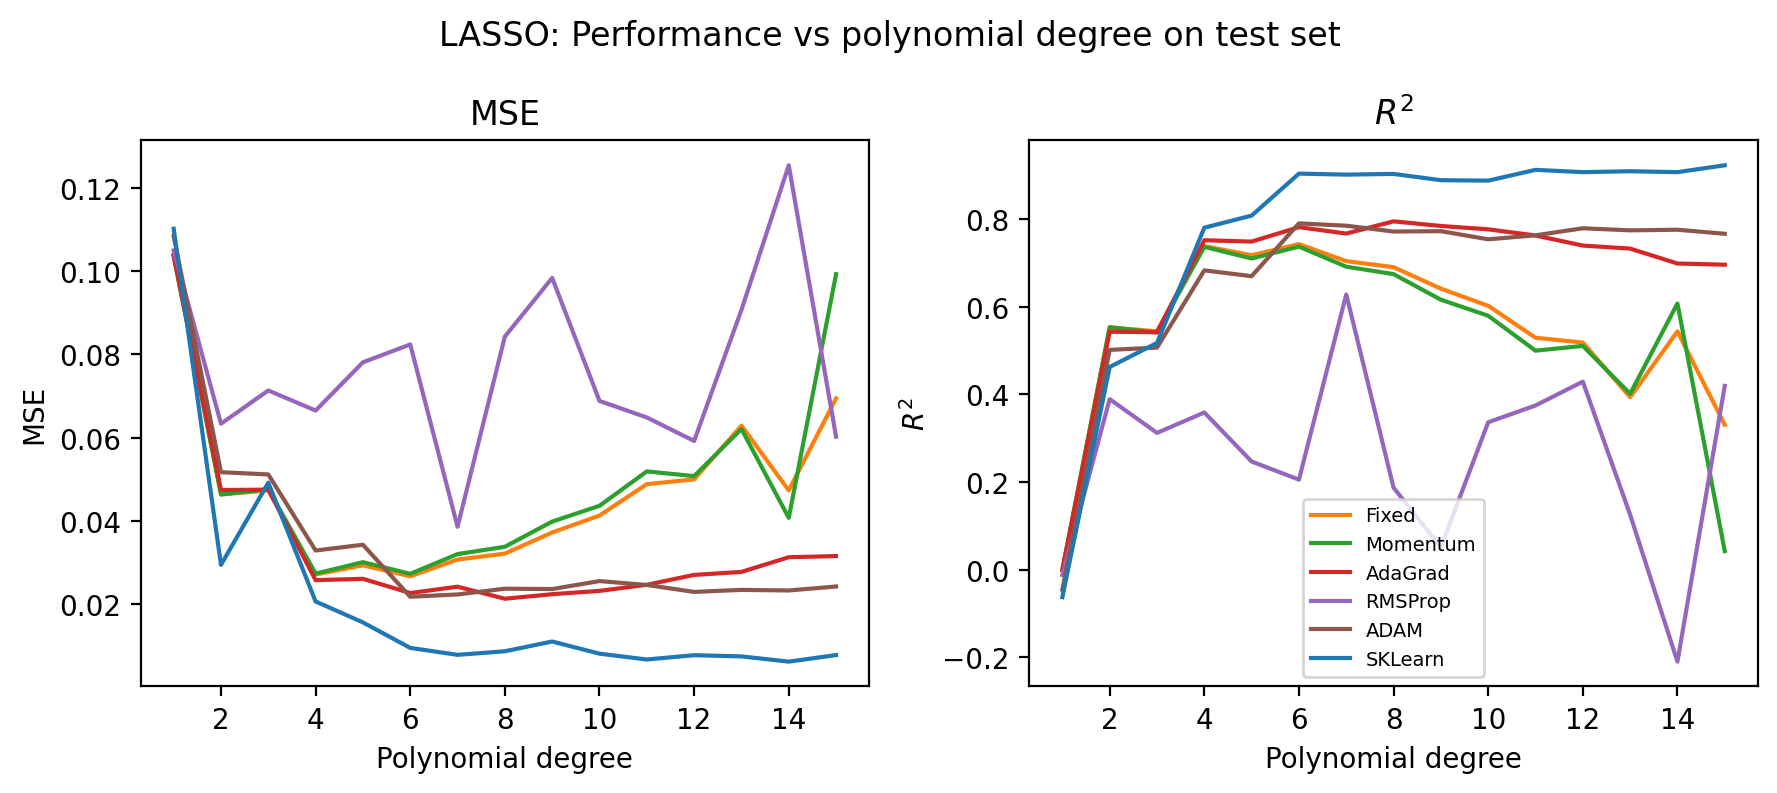

In [5]:
# Analytical, Fixed, Momentum, AdaGrad, RMSProp, ADAM
lasso_mses = []
lasso_r2s = []

for degree in degrees:
    X = PolynomialFeatures(degree = degree).fit_transform(x)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

    # Scaling
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)
    y_offset = np.mean(y_test)

    lasso_mses_degree = []
    lasso_r2s_degree = []

    # Gradient descent solver
    LASSO_grad_descent_solver = gradient_descent(X_train_s, y_train, LASSO_Gradient, learning_rate, hyperparameter = l)
    theta_grad_descent = LASSO_grad_descent_solver.gradient_descent_stochastic(epochs = epochs, minibatch_size = minibatch)
    grad_descent_predictions = X_test_s @ theta_grad_descent + y_offset
    lasso_r2s_degree.append(r2_score(y_test, grad_descent_predictions))
    lasso_mses_degree.append(mean_squared_error(y_test,   grad_descent_predictions))

    # Grad descent + momentum
    theta_momentum = LASSO_grad_descent_solver.momentum_stochastic(alpha = 0.060, epochs=epochs, minibatch_size=minibatch)
    momentum_predictions = X_test_s @ theta_momentum + y_offset
    lasso_r2s_degree.append(r2_score(y_test, momentum_predictions))
    lasso_mses_degree.append(mean_squared_error(y_test, momentum_predictions))

    # Grad descent + AdaGrad
    theta_adagrad = LASSO_grad_descent_solver.AdaGrad_stochastic(epochs=epochs, minibatch_size=minibatch)
    adagrad_predictions = X_test_s @ theta_adagrad + y_offset
    lasso_r2s_degree.append(r2_score(y_test, adagrad_predictions))
    lasso_mses_degree.append(mean_squared_error(y_test, adagrad_predictions))

    # Grad descent + RMSProp
    theta_rmsprop = LASSO_grad_descent_solver.RMSProp_stochastic(rho = 0.99, epochs=epochs, minibatch_size=minibatch)
    rmsprop_predictions = X_test_s @ theta_rmsprop + y_offset
    lasso_r2s_degree.append(r2_score(y_test,rmsprop_predictions))
    lasso_mses_degree.append(mean_squared_error(y_test, rmsprop_predictions))

    # Grad descent + ADAM
    theta_adam = LASSO_grad_descent_solver.ADAM_stochastic(rho1 = 0.9, rho2 = 0.999, epochs=epochs, minibatch_size=minibatch)
    adam_predictions = X_test_s @ theta_adam + y_offset
    lasso_r2s_degree.append(r2_score(y_test, adam_predictions))
    lasso_mses_degree.append(mean_squared_error(y_test, adam_predictions))

    lasso_mses.append(lasso_mses_degree)
    lasso_r2s.append(lasso_r2s_degree)

lasso_mses = np.array(lasso_mses)
lasso_r2s = np.array(lasso_r2s)

methods = ["Fixed", "Momentum", "AdaGrad", "RMSProp", "ADAM"]
plt.figure()
fig, ax = plt.subplots(1,2, figsize = (9,4), dpi = 200)
fig.suptitle("LASSO: Performance vs polynomial degree on test set")

ax[0].set_title("MSE")
ax[1].set_title(r"$R^2$")
ax[0].set_xlabel("Polynomial degree")
ax[1].set_xlabel("Polynomial degree")
ax[0].set_ylabel("MSE")
ax[1].set_ylabel(r"$R^2$")

colors = ["tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]  

for i, method in enumerate(methods):
    ax[0].plot(degrees, lasso_mses[:,i], label = method, color = colors[i])
    ax[1].plot(degrees, lasso_r2s[:,i], label = method, color = colors[i])

lasso_r2s_sklearn, lasso_mses_sklearn = [],[]
for degree in degrees:
    X = PolynomialFeatures(degree = degree).fit_transform(x)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

    # Scaling
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)
    y_offset = np.mean(y_test)

    lasso = Lasso(alpha = l, max_iter = 1000)
    lasso.fit(X_train_s, y_train)

    lasso_pred = lasso.predict(X_test_s)
    lasso_r2s_sklearn.append(r2_score(y_test, lasso_pred))
    lasso_mses_sklearn.append(mean_squared_error(y_test, lasso_pred))

ax[0].plot(degrees, lasso_mses_sklearn, label = "SKLearn", color = "tab:blue")
ax[1].plot(degrees, lasso_r2s_sklearn, label = "SKLearn", color = "tab:blue")

ax[1].legend(prop = {'size': 7})
fig.tight_layout()